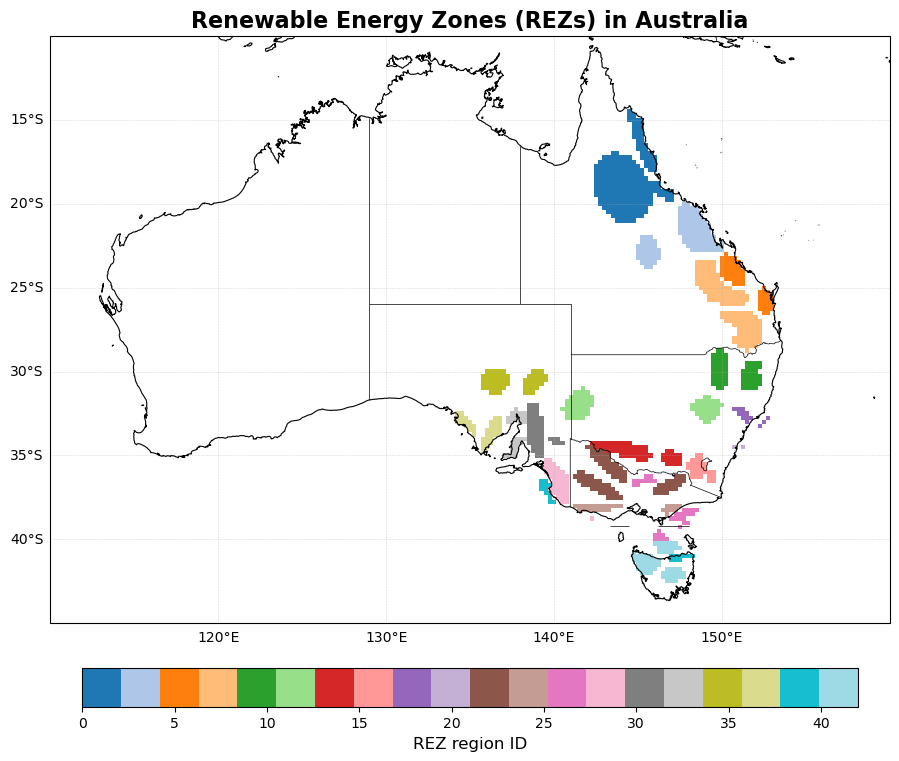

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =====================
# Load REZ mask
# =====================
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

rez = xr.open_dataset(
    rez_file
)["rez_mask"]

# =====================
# Plot
# =====================
fig = plt.figure(
    figsize=(10,8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# REZ mask
cf = ax.pcolormesh(
    rez.longitude,
    rez.latitude,
    rez,
    cmap="tab20",
    transform=ccrs.PlateCarree()
)

# Ocean
# ax.add_feature(
#     cfeature.OCEAN,
#     facecolor="white",
#     edgecolor="none",
#     zorder=100
# )

# Coastline
ax.coastlines(
    resolution="10m",
    linewidth=0.8,
    color="black",
    zorder=101
)

# State boundaries
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.5,
    zorder=102
)

# Extent
ax.set_extent(
    [110,160,-45,-10],
    crs=ccrs.PlateCarree()
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(
    cf,
    orientation="horizontal",
    pad=0.06,
    shrink=0.8
)

cbar.set_label(
    "REZ region ID",
    fontsize=12
)

# Title
plt.title(
    "Renewable Energy Zones (REZs) in Australia",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "REZ_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()